## Import Packages

In [1]:
import os
from pathlib import Path
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(42)

In [3]:
# Select the best available hardware accelerator
if torch.backends.mps.is_available():
    device = torch.device("mps") # Acceleration for macOS (Apple Silicon)
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda") # Acceleration for NVIDIA GPUs
    print("Using CUDA (NVIDIA GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using MPS (Apple Silicon GPU)


## Read and Process Data

In [4]:
# Set dataset path and signal feature names
DataPath = Path("UCI HAR Dataset")  
SignalNames = ["body_acc_x", "body_acc_y", "body_acc_z","total_acc_x","total_acc_y","total_acc_z","body_gyro_x","body_gyro_y","body_gyro_z",]

def load_data(part):
    # Directory for inertial sensor files
    sig_dir = DataPath/part/"Inertial Signals"
    matrices = []
    
    # Load each signal file and add a channel dimension
    for name in SignalNames:
        fpath = sig_dir / f"{name}_{part}.txt"
        arr = np.loadtxt(fpath, dtype=np.float32)
        matrices.append(arr[:, :, None])
    
    # Concatenate signals into a 3D feature matrix (Samples, TimeSteps, Features)
    X = np.concatenate(matrices, axis=2)
    
    # Load labels and adjust to 0-indexed for CrossEntropyLoss
    y = np.loadtxt(DataPath / part / f"y_{part}.txt", dtype=np.int64)
    y = y - 1
    
    # Load subject identifiers
    subjects = np.loadtxt(DataPath / part / f"subject_{part}.txt", dtype=np.int64)

    return X, y, subjects

# Load train and test splits
X_train_np, y_train_np, subj_train = load_data("train")
X_test_np,  y_test_np,  subj_test  = load_data("test")

# Standardize features based on training set statistics
train_mean = X_train_np.mean(axis=(0,1), keepdims=True)
train_std  = X_train_np.std(axis=(0,1),  keepdims=True)
X_train_std = (X_train_np - train_mean) / (train_std)
X_test_std  = (X_test_np  - train_mean) / (train_std)

# Convert NumPy arrays to PyTorch tensors
X_train_t = torch.from_numpy(X_train_std)
y_train_t = torch.from_numpy(y_train_np)
X_test_t  = torch.from_numpy(X_test_std)
y_test_t  = torch.from_numpy(y_test_np) 

# Map integer labels to activity names
activity_map = {
    0: "WALKING",
    1: "WALKING_UPSTAIRS",
    2: "WALKING_DOWNSTAIRS",
    3: "SITTING",
    4: "STANDING",
    5: "LAYING",}

## Data Exploration and Class Distribution Analysis

WALKING: 1226
WALKING_UPSTAIRS: 1073
WALKING_DOWNSTAIRS: 986
SITTING: 1286
STANDING: 1374
LAYING: 1407


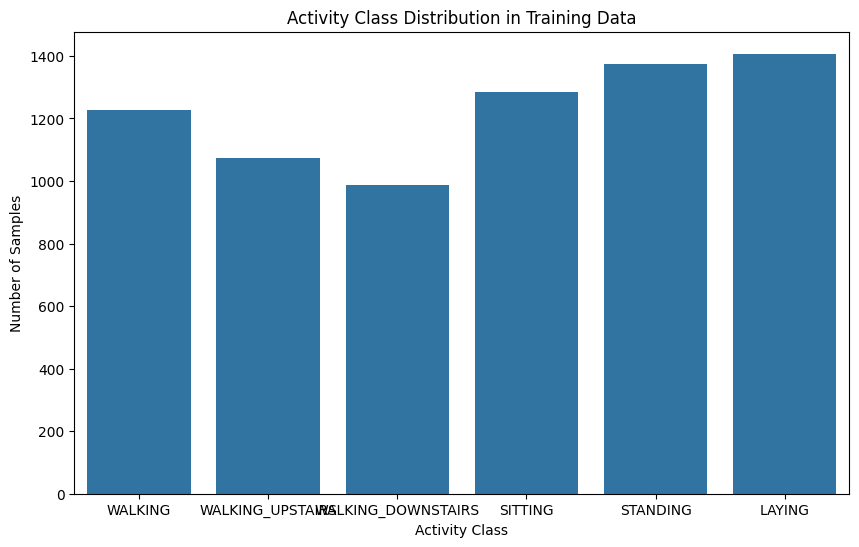

In [5]:
# Compute and display training set class distribution
class_counts = np.bincount(y_train_np) 
for i, activity in enumerate(activity_map.values()):
    print(f"{activity}: {class_counts[i]}")

# Visualize class distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=list(activity_map.values()), y=class_counts)
plt.title("Activity Class Distribution in Training Data")
plt.xlabel("Activity Class")
plt.ylabel("Number of Samples")
plt.show()

## Visualizing Raw Sensor Signals

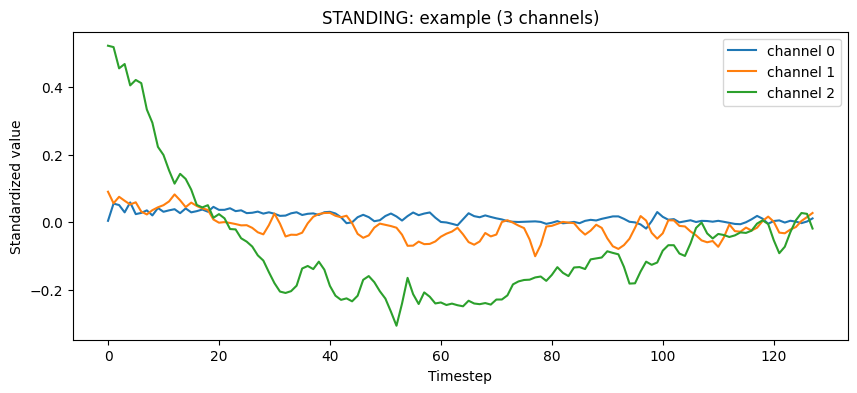

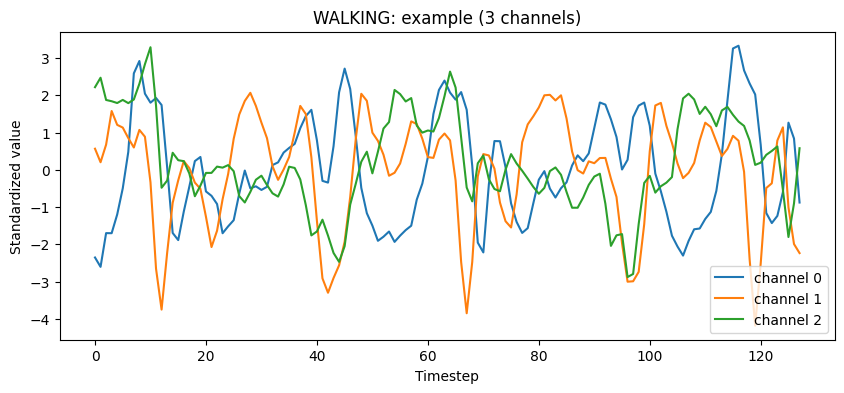

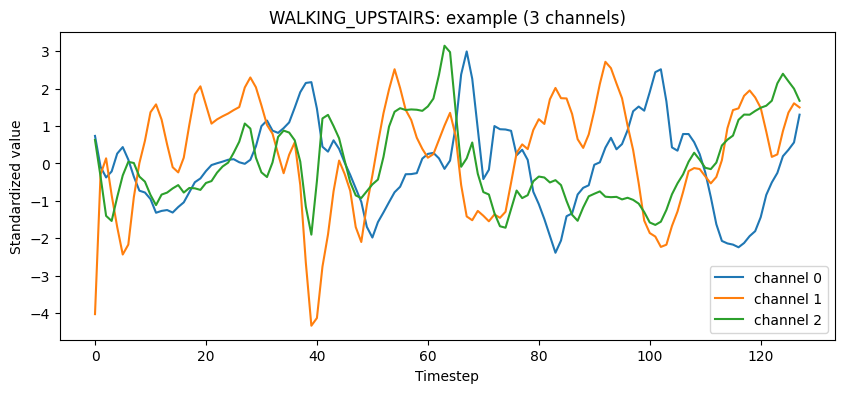

In [6]:
# Visualize signal patterns for specific samples
for idx in [0, 100, 500]:
    # Create time axis based on the number of timesteps (128)
    time = np.arange(X_train_std[idx].shape[0])
    plt.figure(figsize=(10, 4))
    # Plot the first three channels (e.g., Body Acc X, Y, Z)
    for c in [0, 1, 2]:
        plt.plot(time, X_train_std[idx][:, c], label=f"channel {c}")
    plt.xlabel("Timestep")
    plt.ylabel("Standardized value")
    # Title showing the activity name from the map for the given sample
    plt.title(f"{activity_map[y_train_np[idx]]}: example (3 channels)")
    plt.legend()
    plt.show()

## Class-Wise Average Signal Analysis

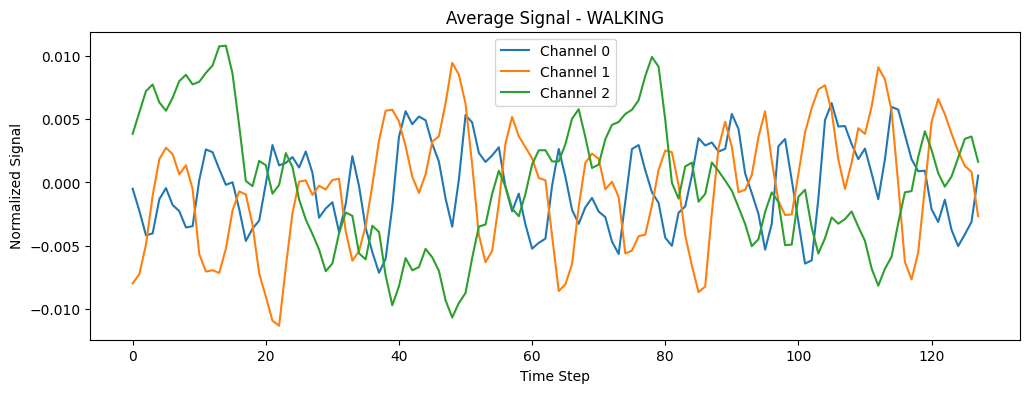

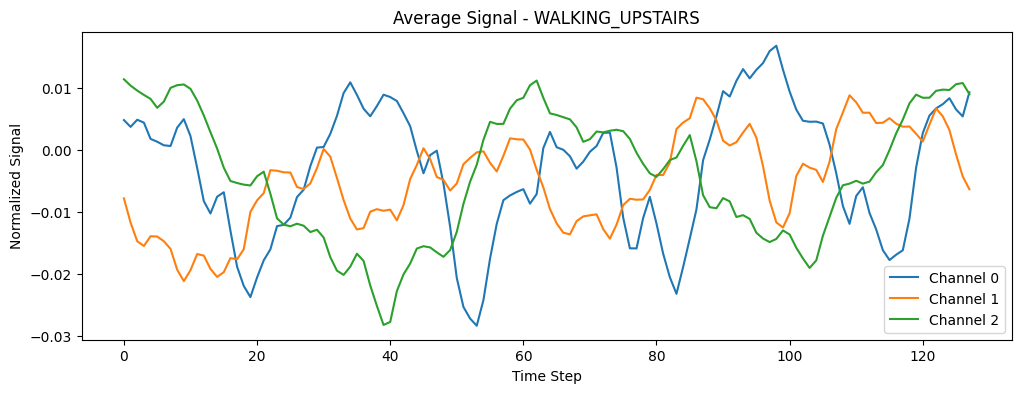

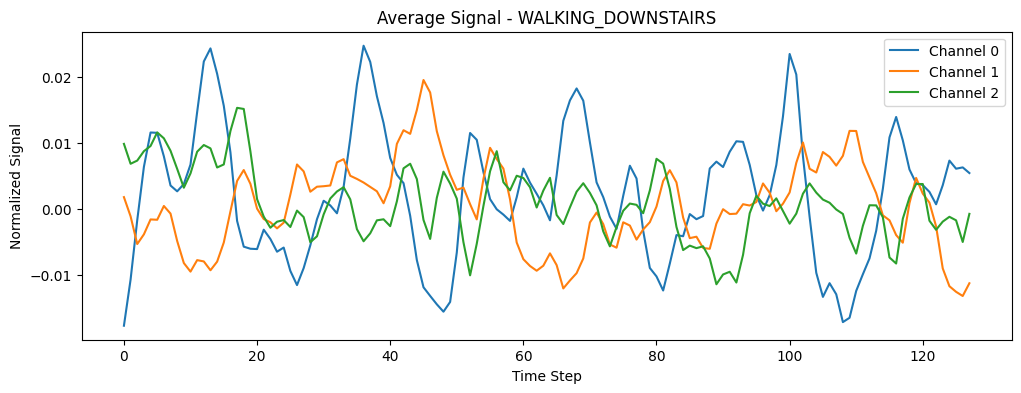

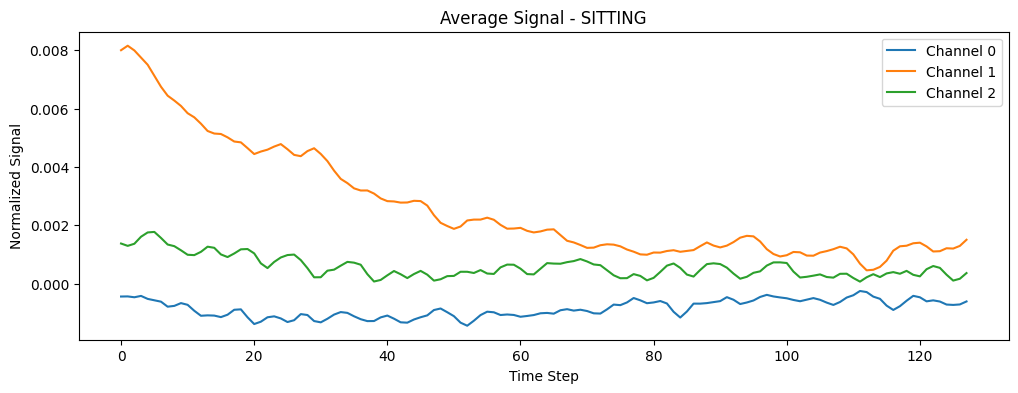

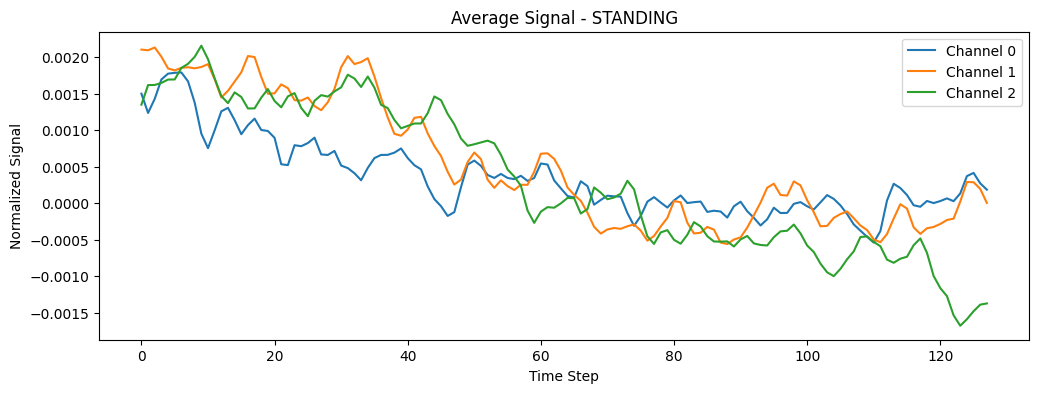

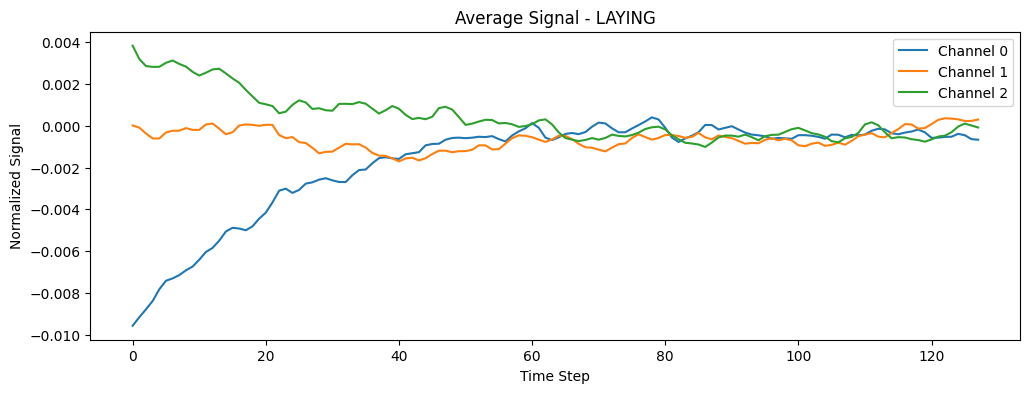

In [7]:
# Select indices for the first three accelerometer channels
channels_to_plot = [0, 1, 2]

# Iterate through each activity to compute and plot its average signal profile
for class_id, class_name in activity_map.items():
    # Filter training data for the current class
    class_data = X_train_np[y_train_np == class_id]
    # Calculate the mean signal across all samples of this activity
    mean_signal = class_data.mean(axis=0)
    plt.figure(figsize=(12,4))
    # Plot the average trend for each selected channel
    for ch in channels_to_plot:
        plt.plot(mean_signal[:, ch], label=f'Channel {ch}')
        
    plt.title(f'Average Signal - {class_name}')
    plt.xlabel('Time Step')
    plt.ylabel('Normalized Signal')
    plt.legend()
    plt.show()

## Temporal Variance Analysis per Activity

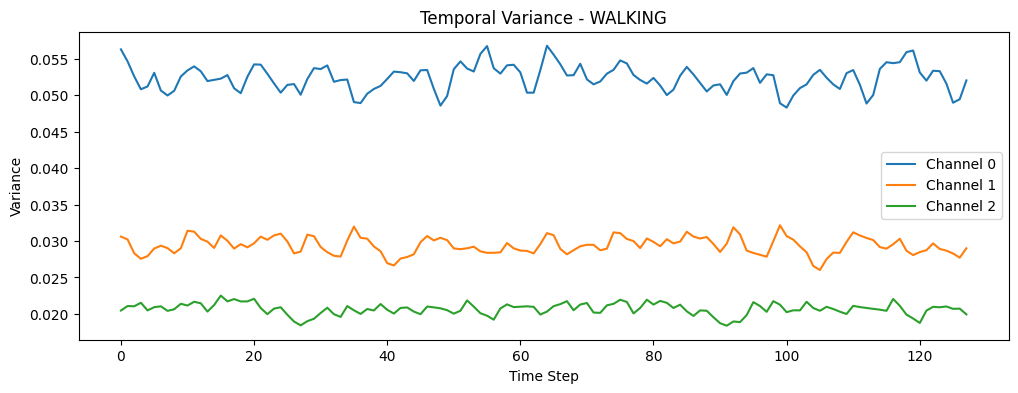

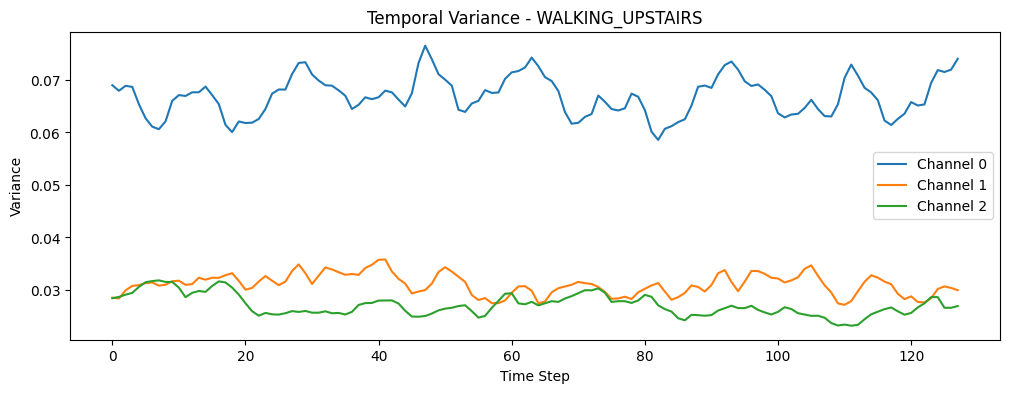

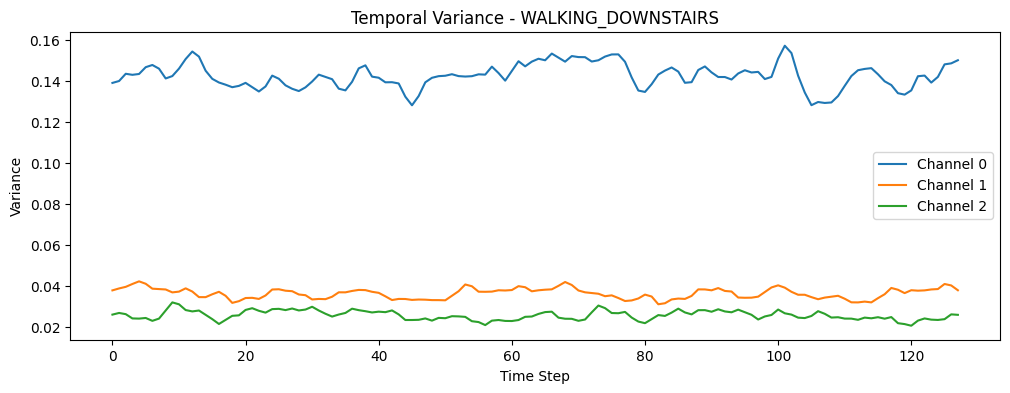

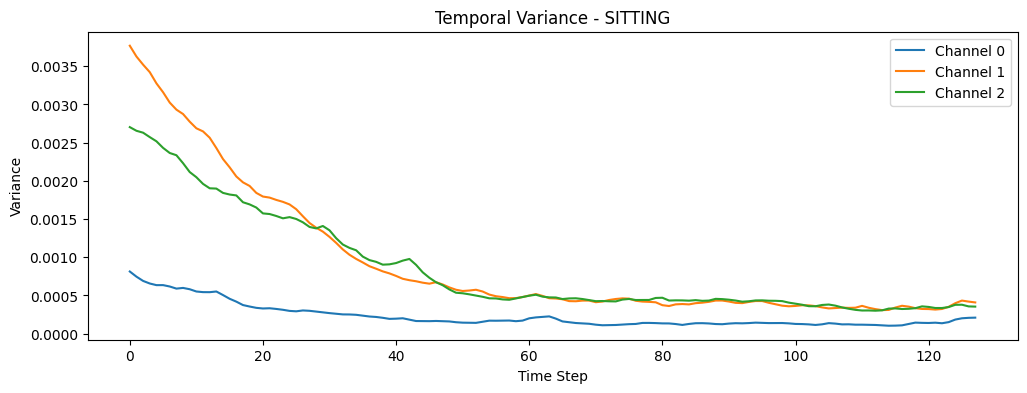

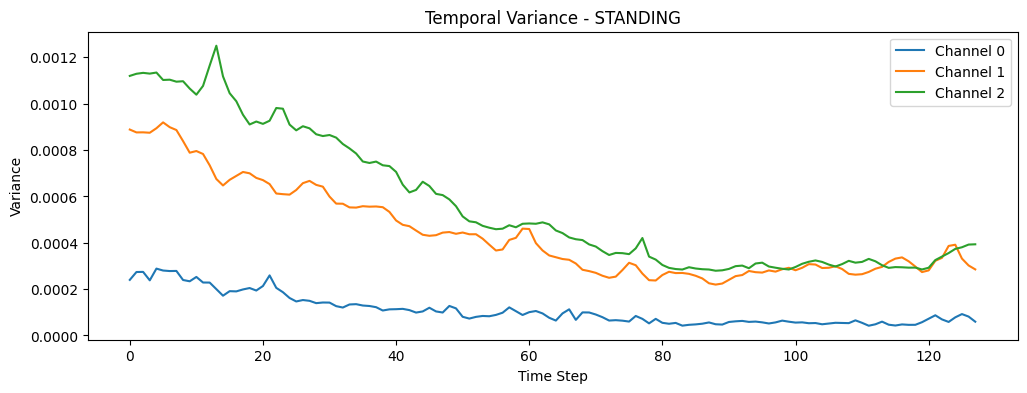

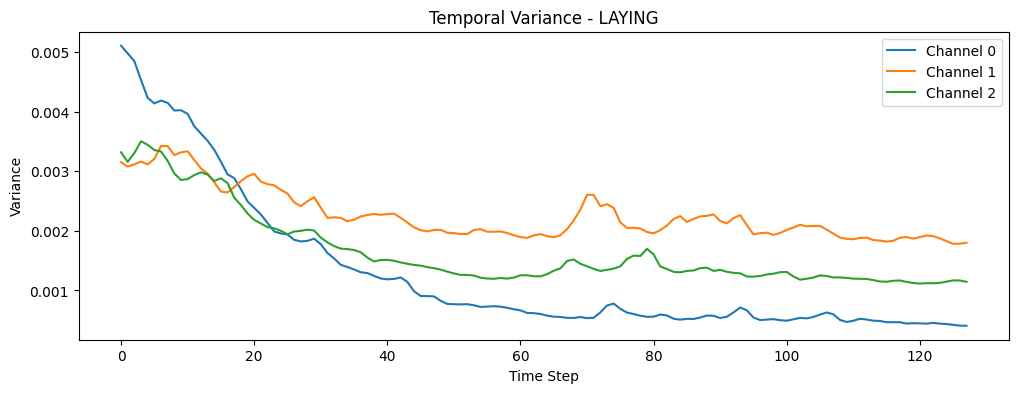

In [8]:
# Iterate through each activity to analyze signal stability over time
for class_id, class_name in activity_map.items():
    # Filter training data for samples belonging to the current class
    class_data = X_train_np[y_train_np == class_id]
    # Compute variance at each timestep across all samples in the class
    temporal_variance = class_data.var(axis=0)
    plt.figure(figsize=(12,4))
    # Plot variance for selected channels to identify periods of high/low signal volatility
    for ch in channels_to_plot:
        plt.plot(temporal_variance[:, ch], label=f'Channel {ch}')
    plt.title(f'Temporal Variance - {class_name}')
    plt.xlabel('Time Step')
    plt.ylabel('Variance')
    plt.legend()
    plt.show()

## Feature Correlation AnalysisFeature Correlation Analysis

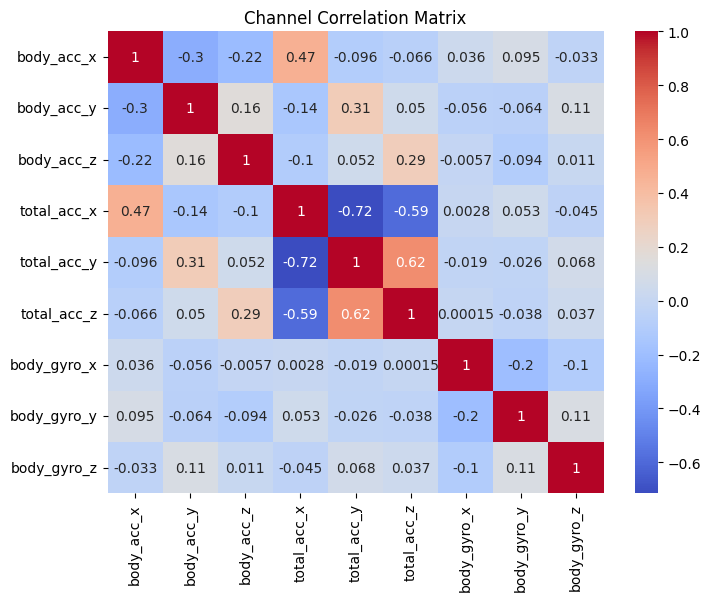

In [9]:
# Flatten the 3D data into a 2D matrix (Total Timesteps x 9 Channels)
flattened = X_train_np.reshape(-1, 9)
# Compute the Pearson correlation matrix between the 9 sensor channels
corr_matrix = pd.DataFrame(flattened, columns=SignalNames).corr()
plt.figure(figsize=(8,6))
# Visualize the correlation between axes (e.g., X, Y, Z) and different sensor types
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Channel Correlation Matrix')
plt.show()

# Models

## Vanilla RNN Model Architecture

In [10]:
class VanillaRNNClassifier(nn.Module):
    def __init__(self, input_size=9, hidden_size=64, num_classes=6):
        super(VanillaRNNClassifier, self).__init__()
        self.hidden_size = hidden_size
        # Initialize basic RNN layer with batch_first=True for (Batch, Seq, Feature) input
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        # Fully connected layer to map RNN hidden state to class logits
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        # Forward pass through RNN: 'out' contains all hidden states, 'h_n' is the last one
        out, h_n = self.rnn(x, h0)
        # Extract the final hidden state and remove the layer dimension
        final_hidden = h_n.squeeze(0)
        # Pass the final hidden state through the classifier
        logits = self.fc(final_hidden)
        
        return logits, out

### Data Loading and Model Training Initialization

In [11]:
# Create DataLoaders for batch processing and shuffling during training
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=32, shuffle=True, drop_last=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                          batch_size=32, shuffle=False, drop_last=False)
# Initialize model, loss function, and Adam optimizer
model = VanillaRNNClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

# Execute a single training epoch across the dataset
for x_batch, y_batch in train_loader:
    # Reset gradients for each batch
    optimizer.zero_grad()
    # Forward pass to obtain class logits
    logits, _ = model(x_batch)
    # Calculate loss and perform backpropagation
    loss = criterion(logits, y_batch)
    loss.backward()
    # Update model weights based on gradients
    optimizer.step()

### Model Evaluation and Performance Metrics

In [15]:
model.to(device) 
model.eval()

test_loss = 0
# Initialize lists to store outputs for comprehensive performance analysis
all_preds = []
all_labels = []
all_hidden = []
all_inputs = []


# Disable gradient calculation to save memory and compute during inference
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        # Get predictions and temporal hidden states from the model
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        logits, out = model(x_batch)

        loss = criterion(logits, y_batch)
        test_loss += loss.item()
        # Convert logits to class indices by selecting the maximum value
        preds = torch.argmax(logits, dim=1)

        # Move data to CPU and store for final metrics
        all_preds.append(preds.cpu())
        all_labels.append(y_batch.cpu())
        all_hidden.append(out.cpu())
        all_inputs.append(x_batch.cpu())

# Concatenate batch results into single arrays for global evaluation
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
all_hidden = torch.cat(all_hidden, dim=0)
all_inputs = torch.cat(all_inputs, dim=0)

# Calculate and display the average loss across the test set
avg_test_loss = test_loss / len(test_loader)
print("Test Loss:", avg_test_loss)

# Generate and print the confusion matrix and detailed classification report
cm = confusion_matrix(all_labels, all_preds)
print(classification_report(all_labels, all_preds, zero_division=0))

Test Loss: 1.1682721589922265
              precision    recall  f1-score   support

           0       0.29      0.02      0.04       496
           1       0.39      0.87      0.54       471
           2       0.00      0.00      0.00       420
           3       0.50      0.88      0.64       491
           4       0.62      0.58      0.60       532
           5       1.00      0.95      0.97       537

    accuracy                           0.57      2947
   macro avg       0.47      0.55      0.46      2947
weighted avg       0.49      0.57      0.48      2947



### Identifying Significant Inter-Class Confusion

In [16]:
# Determine the number of classes from the confusion matrix dimensions
num_classes = cm.shape[0]

# Iterate through the confusion matrix to find off-diagonal (error) entries
for i in range(num_classes):
    for j in range(num_classes):
        # Identify major misclassifications where errors exceed a threshold of 50 samples
        if i != j and cm[i, j] > 50:
            print(f"Class {i} is confused with Class {j}: {cm[i, j]}")

Class 0 is confused with Class 1: 292
Class 0 is confused with Class 3: 131
Class 0 is confused with Class 4: 63
Class 2 is confused with Class 1: 211
Class 2 is confused with Class 3: 109
Class 2 is confused with Class 4: 79
Class 4 is confused with Class 1: 88
Class 4 is confused with Class 3: 136


### Analyzing Normalized Confusion Matrix and Major Misclassification Pairs

In [17]:
# Normalize the confusion matrix by the total number of samples in each class
cm_norm = cm / cm.sum(axis=1, keepdims=True)
pairs = []
# Scan for significant errors where a class is misclassified over 20% of the time
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm_norm[i, j] > 0.2:
            # Store the actual class, predicted class, and the error rate
            pairs.append((i, j, float(cm_norm[i, j])))
# Sort the misclassification pairs by the error rate in descending order
pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
print(pairs)

[(0, 1, 0.5887096774193549), (2, 1, 0.5023809523809524), (0, 3, 0.26411290322580644), (2, 3, 0.25952380952380955), (4, 3, 0.2556390977443609)]


### Dimensionality Reduction of Hidden States for Class Separation Analysis

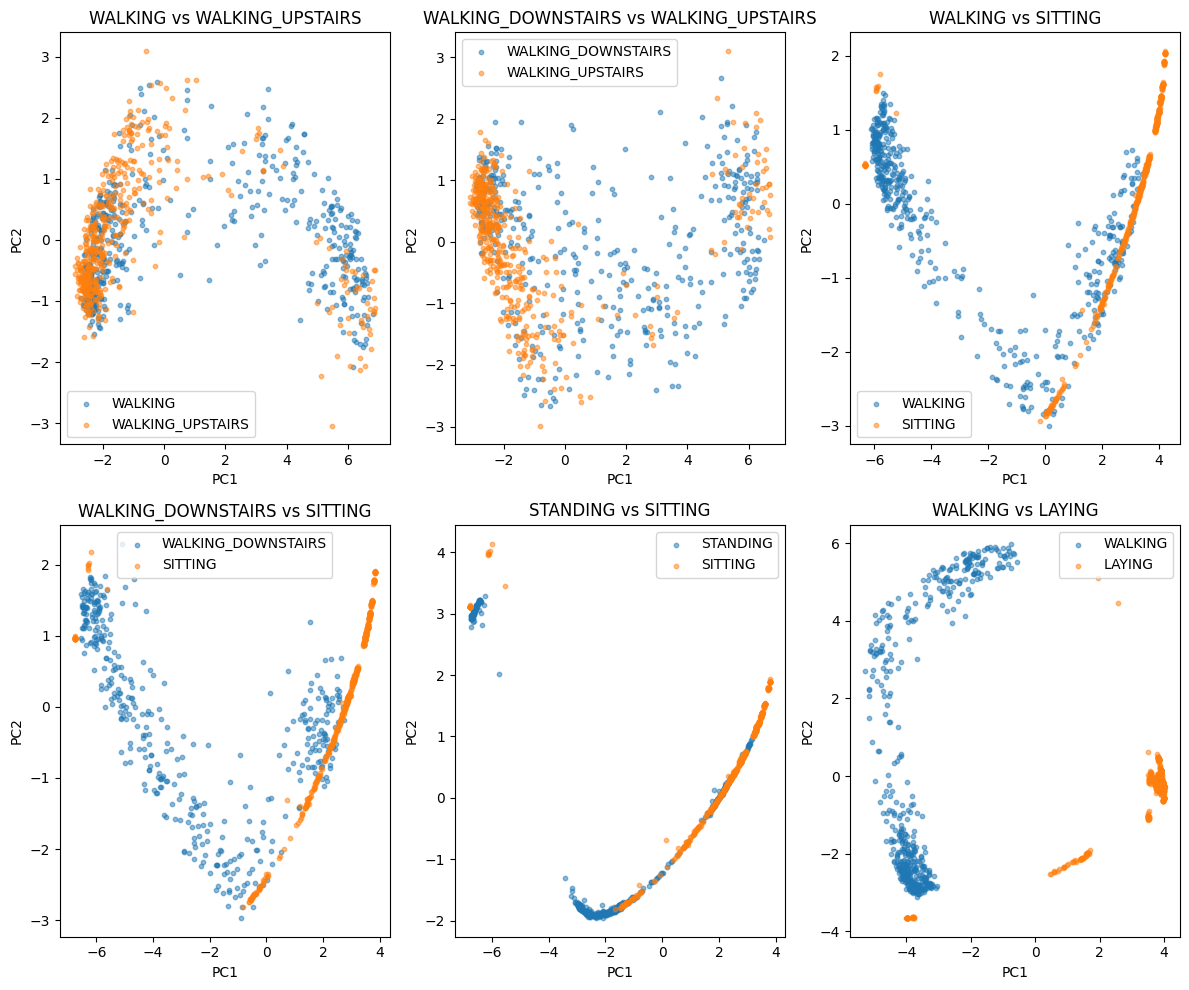

In [18]:
def get_class_hidden(class_idx):
    # Filter hidden states for a specific activity class
    mask = (all_labels == class_idx)
    hidden_seqs = all_hidden[mask]
    # Extract only the hidden state from the final timestep
    last_hidden = hidden_seqs[:, -1, :] 
    return last_hidden.numpy()

def plot_hidden_separation(class_a, class_b, ax):
    # Retrieve final hidden states for two classes to compare
    h_a, h_b = get_class_hidden(class_a), get_class_hidden(class_b)
    X = np.concatenate([h_a, h_b])
    y = np.array([class_a] * len(h_a) + [class_b] * len(h_b))

    # Apply PCA to reduce 128D hidden vectors to 2D for visualization
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    label_a, label_b = activity_map[class_a], activity_map[class_b]

    # Plot the clusters to visualize how well the model separates the two activities
    ax.scatter(X_2d[y == class_a, 0], X_2d[y == class_a, 1], label=label_a, alpha=0.5, s=10)
    ax.scatter(X_2d[y == class_b, 0], X_2d[y == class_b, 1], label=label_b, alpha=0.5, s=10)
    ax.set_title(f'{label_a} vs {label_b}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()

# Create a grid of subplots for pairwise class comparisons
fig, axes = plt.subplots(2,3, figsize=(12,10))

# Execute PCA plots for specific activity pairs to identify boundary overlaps
plot_hidden_separation(0, 1, axes[0,0])
plot_hidden_separation(2, 1, axes[0,1])
plot_hidden_separation(0, 3, axes[0,2])
plot_hidden_separation(2, 3, axes[1,0])
plot_hidden_separation(4, 3, axes[1,1])
plot_hidden_separation(0, 5, axes[1,2])

plt.tight_layout()
plt.show()

### Visualizing RNN Hidden State Trajectories over Time

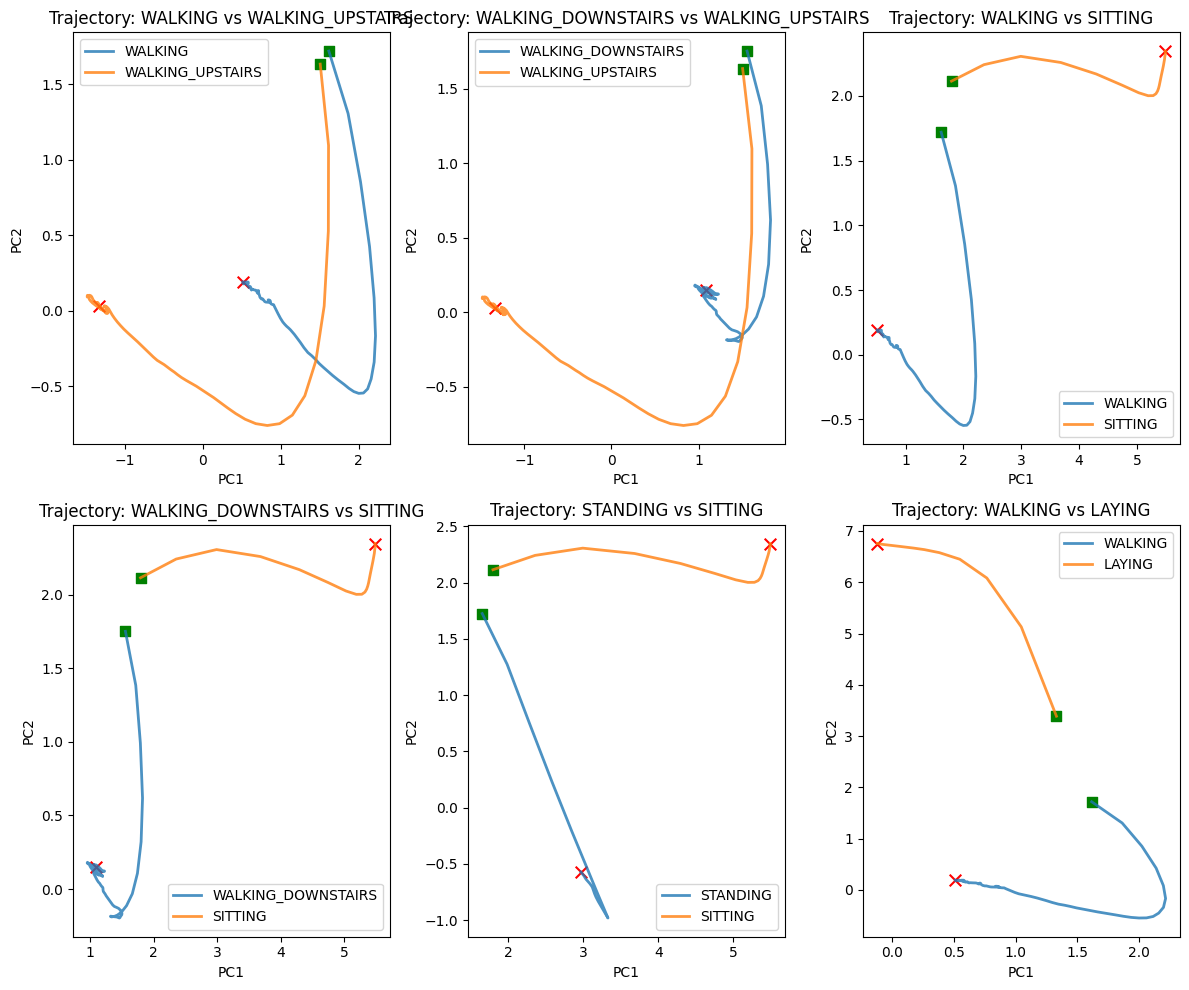

In [19]:
def get_full_trajectory(class_idx):
    # Filter hidden states for the specific activity class
    mask = (all_labels == class_idx)
    hidden_seqs = all_hidden[mask] 
    # Calculate the average hidden state trajectory across all samples in the class
    avg_trajectory = hidden_seqs.mean(axis=0)
    return avg_trajectory.numpy()

def plot_trajectory(class_a, class_b, ax, pca=None, fit_pca=False):
    # Retrieve mean trajectories for two activities
    traj_a = get_full_trajectory(class_a)
    traj_b = get_full_trajectory(class_b)

    seq_len = traj_a.shape[0] 
    combined = np.concatenate([traj_a, traj_b], axis=0) 

    # Fit PCA or transform the combined trajectories into a 2D space
    if fit_pca or pca is None:
        pca = PCA(n_components=2)
        combined_2d = pca.fit_transform(combined)
    else:
        combined_2d = pca.transform(combined)
    
    traj_a_2d = combined_2d[:seq_len]
    traj_b_2d = combined_2d[seq_len:]
    label_a = activity_map[class_a]
    label_b = activity_map[class_b]

    # Plot the temporal flow of hidden states for each class
    ax.plot(traj_a_2d[:, 0], traj_a_2d[:, 1], label=label_a, linewidth=2, alpha=0.8)
    ax.plot(traj_b_2d[:, 0], traj_b_2d[:, 1], label=label_b, linewidth=2, alpha=0.8)
    
    # Mark the start (Green Square) and end (Red X) points of the sequence
    ax.scatter(traj_a_2d[0, 0], traj_a_2d[0, 1], c='green', marker='s', s=50) 
    ax.scatter(traj_a_2d[-1, 0], traj_a_2d[-1, 1], c='red', marker='x', s=70)  
    
    ax.scatter(traj_b_2d[0, 0], traj_b_2d[0, 1], c='green', marker='s', s=50) 
    ax.scatter(traj_b_2d[-1, 0], traj_b_2d[-1, 1], c='red', marker='x', s=70)  

    ax.set_title(f'Trajectory: {label_a} vs {label_b}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()

    return pca
    
# Visualize pairwise hidden state trajectories to analyze model dynamics
fig, axes = plt.subplots(2, 3, figsize=(12,10))

pca = None
pca = plot_trajectory(0, 1, axes[0,0], pca, fit_pca=True)
pca = plot_trajectory(2, 1, axes[0,1], pca)
pca = plot_trajectory(0, 3, axes[0,2], pca)
pca = plot_trajectory(2, 3, axes[1,0], pca)
pca = plot_trajectory(4, 3, axes[1,1], pca)
pca = plot_trajectory(0, 5, axes[1,2], pca)

plt.tight_layout()
plt.show()

### Analysis of Model Failure Dynamics

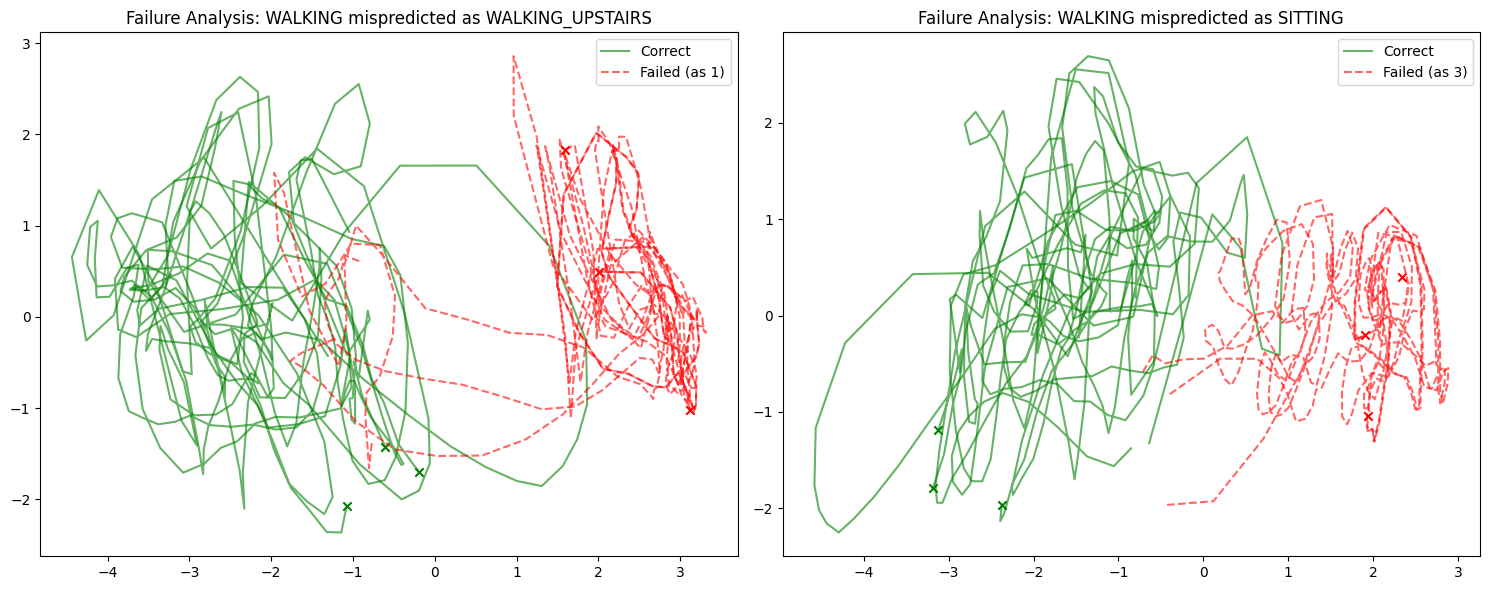

In [21]:
def get_failure_trajectories(target_class, pred_class, num_samples=3):
    # Identify indices where the model failed (misclassified) vs. succeeded for a specific class
    mask_fail = (all_labels == target_class) & (all_preds == pred_class)
    mask_correct = (all_labels == target_class) & (all_preds == target_class)
    
    # Extract a subset of hidden state sequences for both failure and success cases
    fail_seqs = all_hidden[mask_fail][:num_samples].numpy()
    correct_seqs = all_hidden[mask_correct][:num_samples].numpy()
    return fail_seqs, correct_seqs

def plot_failure_dynamics(target_class, mispredicted_as, ax):
    # Retrieve hidden state paths for correct and incorrect predictions
    fail_seqs, correct_seqs = get_failure_trajectories(target_class, mispredicted_as)
    all_seqs = np.concatenate([fail_seqs, correct_seqs], axis=0)
    seq_len = fail_seqs.shape[1]
    
    # Use PCA to project high-dimensional hidden state transitions into 2D space
    pca = PCA(n_components=2)
    flat_data = all_seqs.reshape(-1, 64)
    pca.fit(flat_data)
    
    # Plot successful trajectories in green to show the 'correct' decision path
    for i in range(len(correct_seqs)):
        traj_2d = pca.transform(correct_seqs[i])
        ax.plot(traj_2d[:, 0], traj_2d[:, 1], color='green', alpha=0.6, label='Correct' if i==0 else "")
        ax.scatter(traj_2d[-1, 0], traj_2d[-1, 1], color='green', marker='x')
        
    # Plot failed trajectories in red to visualize where the model's logic diverged
    for i in range(len(fail_seqs)):
        traj_2d = pca.transform(fail_seqs[i])
        ax.plot(traj_2d[:, 0], traj_2d[:, 1], color='red', alpha=0.6, linestyle='--', label=f'Failed (as {mispredicted_as})' if i==0 else "")
        ax.scatter(traj_2d[-1, 0], traj_2d[-1, 1], color='red', marker='x')

    # Add descriptive titles and legends for diagnostic clarity
    ax.set_title(f'Failure Analysis: {activity_map[target_class]} mispredicted as {activity_map[mispredicted_as]}')
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Analyze why the model confuses Class 0 with Class 1 (e.g., Walking vs. Walking_upstairs)
plot_failure_dynamics(target_class=0, mispredicted_as=1, ax=axes[0])
# Analyze why the model confuses Class 0 with Class 4 (e.g., Walking vs. Sitting)
plot_failure_dynamics(target_class=0, mispredicted_as=3, ax=axes[1])
# Adjust layout to prevent overlap and display the diagnostic plots
plt.tight_layout()
plt.show()

### Memory Decay and Temporal Accuracy Analysis

Accuracy at step 10: 53.00%
Accuracy at step 20: 54.46%
Accuracy at step 40: 56.09%
Accuracy at step 60: 56.53%
Accuracy at step 80: 56.46%
Accuracy at step 100: 56.53%
Accuracy at step 128: 56.53%


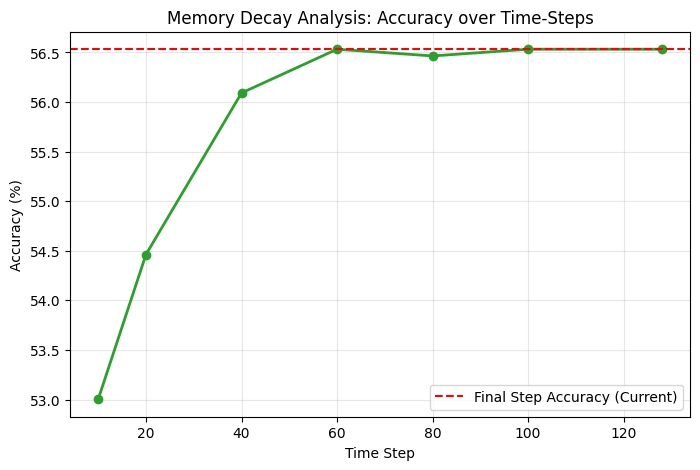

In [23]:
def analyze_temporal_accuracy(model, test_loader):
    # Set the model to evaluation mode
    model.eval()
    current_device = next(model.parameters()).device
    
    # Define specific checkpoints in the 128-timestep sequence to evaluate
    time_steps = [10, 20, 40, 60, 80, 100, 128]
    step_accuracies = []

    with torch.no_grad():
        for step in time_steps:
            correct = 0
            total = 0
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(current_device), labels.to(current_device)
                
                # Extract hidden states for all timesteps
                rnn_out, _ = model.rnn(inputs)
                
                # Slice the output to simulate a prediction made at an earlier point in time
                current_hidden = rnn_out[:, step-1, :]
                
                # Pass the intermediate hidden state through the classification head
                outputs = model.fc(current_hidden)
                _, predicted = torch.max(outputs.data, 1)
                
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            
            # Calculate accuracy percentage for the current truncated sequence length
            acc = 100 * correct / total
            step_accuracies.append(acc)
            print(f"Accuracy at step {step}: {acc:.2f}%")
            
    return time_steps, step_accuracies

# Execute the temporal analysis to see how prediction confidence evolves over time
steps, accs = analyze_temporal_accuracy(model, test_loader)

# Visualize the relationship between sequence duration and classification performance
plt.figure(figsize=(8, 5))
plt.plot(steps, accs, marker='o', linestyle='-', color='#2ca02c', linewidth=2)
# Reference line to compare intermediate performance against the final result
plt.axhline(y=56.53, color='r', linestyle='--', label='Final Step Accuracy (Current)')
plt.title("Memory Decay Analysis: Accuracy over Time-Steps")
plt.xlabel("Time Step")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Feature Attribution: Input Channel Sensitivity Analysis

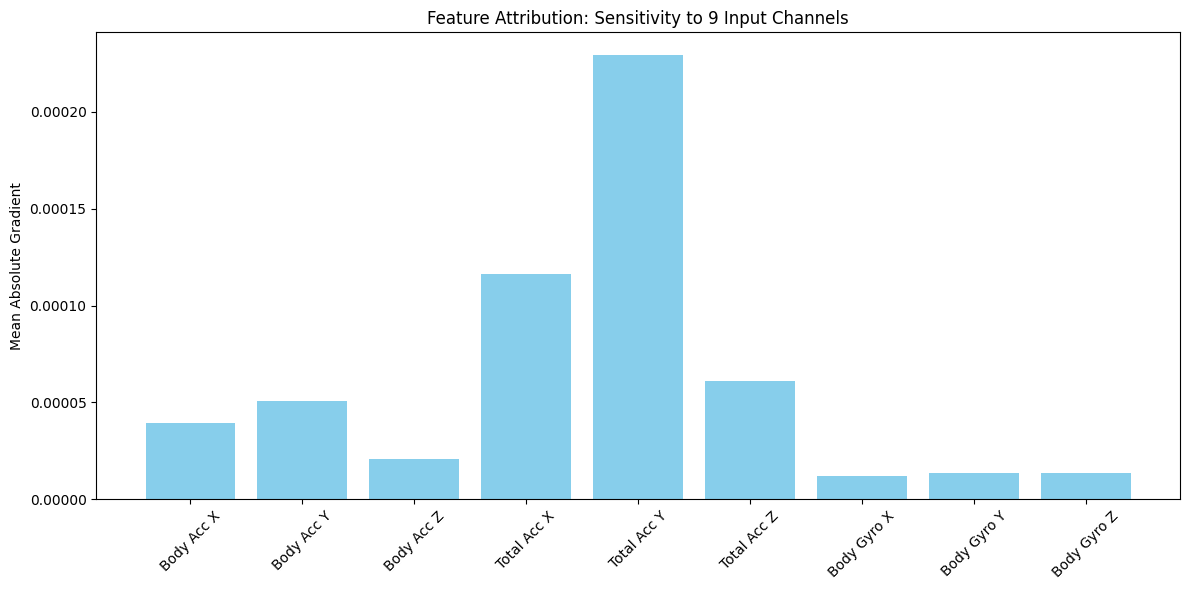

In [24]:
def analyze_feature_attribution(model, test_loader):
    # Enable training mode to allow gradient computation for input sensitivity
    model.train() 
    current_device = next(model.parameters()).device
    
    total_attr = torch.zeros(9) 
    count = 0
    
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(current_device), labels.to(current_device)
        # Enable tracking of gradients with respect to the input features
        inputs.requires_grad = True
        
        # Handle models that return both logits and hidden states (like our RNN)
        results = model(inputs)
        outputs = results[0] if isinstance(results, tuple) else results
        
        # Calculate loss and perform backpropagation to the input layer
        loss = torch.nn.CrossEntropyLoss()(outputs, labels)
        loss.backward()
        
        # Attribute importance based on the mean absolute gradient across batches and time
        attr = inputs.grad.abs().mean(dim=(0, 1)) 
        total_attr += attr.detach().cpu()
        count += 1
        model.zero_grad()
        
    # Calculate the average importance of each sensor channel
    avg_attr = total_attr / count
    feature_names = [
        'Body Acc X', 'Body Acc Y', 'Body Acc Z',
        'Total Acc X', 'Total Acc Y', 'Total Acc Z',
        'Body Gyro X', 'Body Gyro Y', 'Body Gyro Z'
    ]
    
    # Visualize which sensors (Accelerometer vs. Gyroscope) most influence model decisions
    plt.figure(figsize=(12, 6))
    plt.bar(feature_names, avg_attr, color='skyblue')
    plt.xticks(rotation=45)
    plt.title("Feature Attribution: Sensitivity to 9 Input Channels")
    plt.ylabel("Mean Absolute Gradient")
    plt.tight_layout()
    plt.show()

analyze_feature_attribution(model, test_loader)

## Model Enhancement: Vanilla RNN with Global Average Pooling (GAP)

In [25]:
class VanillaRNN_GAP(nn.Module):
    def __init__(self, input_size=9, hidden_size=64, num_classes=6):
        super(VanillaRNN_GAP, self).__init__()
        # Standard RNN layer that processes the full sequence of 9 sensor channels
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        # Linear layer to classify the pooled representation into 6 activity categories
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # 'out' contains the hidden states for every timestep in the sequence
        out, _ = self.rnn(x)
        
        # Global Average Pooling: Compute the mean of hidden states across all timesteps
        # This reduces sensitivity to the specific timing of movements within the window
        out_pooled = torch.mean(out, dim=1)
        
        # Pass the aggregated temporal information to the final classifier
        logits = self.fc(out_pooled)
        return logits

# Initialize the GAP-enhanced model, optimizer, and loss function
GAP_model = VanillaRNN_GAP()
optimizer = torch.optim.Adam(GAP_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Training loop for a single epoch using the GAP architecture
for x_batch, y_batch in train_loader:
    optimizer.zero_grad()
    # Forward pass through the pooling layer to get class logits
    GAP_logits = GAP_model(x_batch)
    GAP_loss = criterion(GAP_logits, y_batch)
    
    # Backpropagation and weight updates
    GAP_loss.backward()
    optimizer.step()

def test_gap_model(model, test_loader):
    """
    Evaluates the performance of the GAP model on the test dataset.
    """
    model.eval()
    current_device = next(model.parameters()).device
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(current_device), labels.to(current_device)
            
            # Generate predictions
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate and display performance metrics
    accuracy = accuracy_score(all_labels, all_preds)
    print(f"Overall Accuracy with GAP: {accuracy * 100:.2f}%")
    print("Classification Report:")
    # Map numerical indices back to human-readable activity names for the report
    print(classification_report(all_labels, all_preds, target_names=list(activity_map.values())))
    
    return all_labels, all_preds

# Run the evaluation and store results for further analysis
labels, preds = test_gap_model(GAP_model, test_loader)

Overall Accuracy with GAP: 68.41%

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.42      0.99      0.59       496
  WALKING_UPSTAIRS       0.25      0.01      0.01       471
WALKING_DOWNSTAIRS       0.88      0.48      0.62       420
           SITTING       0.87      0.67      0.76       491
          STANDING       0.76      0.90      0.82       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.68      2947
         macro avg       0.69      0.67      0.63      2947
      weighted avg       0.70      0.68      0.64      2947



## LSTM

### Multi-Layer LSTM Training

In [26]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, num_layers=2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Multi-layer LSTM with dropout to mitigate overfitting during complex feature extraction
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=0.2)
        
        # Classification head for the 6 human activity categories
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # Extract temporal features; 'out' shape is (batch, seq_len, hidden_size)
        out, _ = self.lstm(x)
        
        # Many-to-One: Focus on the last hidden state to capture the full sequence context
        out_last = out[:, -1, :]
        
        # Map the final temporal representation to class scores
        logits = self.fc(out_last)
        return logits

# Initialize model hyperparameters and move architecture to the selected device
num_epochs = 30
model = LSTMModel(input_size=9, hidden_size=128, num_classes=6, num_layers=2)
model.to(device)

# Set up the Adam optimizer and CrossEntropy loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

print("Starting Training with LSTM...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for x_batch, y_batch in train_loader:
        # Transfer batch data to GPU/MPS memory
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        # Standard PyTorch training step
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # Log progress every 5 epochs to monitor convergence
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

print("Training Finished!")

Starting Training with LSTM...
Epoch [5/30], Loss: 0.1316
Epoch [10/30], Loss: 0.1044
Epoch [15/30], Loss: 0.1086
Epoch [20/30], Loss: 0.1273
Epoch [25/30], Loss: 0.1048
Epoch [30/30], Loss: 0.1076
Training Finished!


### Comprehensive LSTM Performance Evaluation


--- LSTM Performance Report ---
                    precision    recall  f1-score   support

           WALKING       1.00      0.94      0.97       496
  WALKING_UPSTAIRS       0.95      0.98      0.96       471
WALKING_DOWNSTAIRS       0.93      0.99      0.96       420
           SITTING       0.78      0.83      0.81       491
          STANDING       0.87      0.79      0.83       532
            LAYING       0.99      1.00      0.99       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



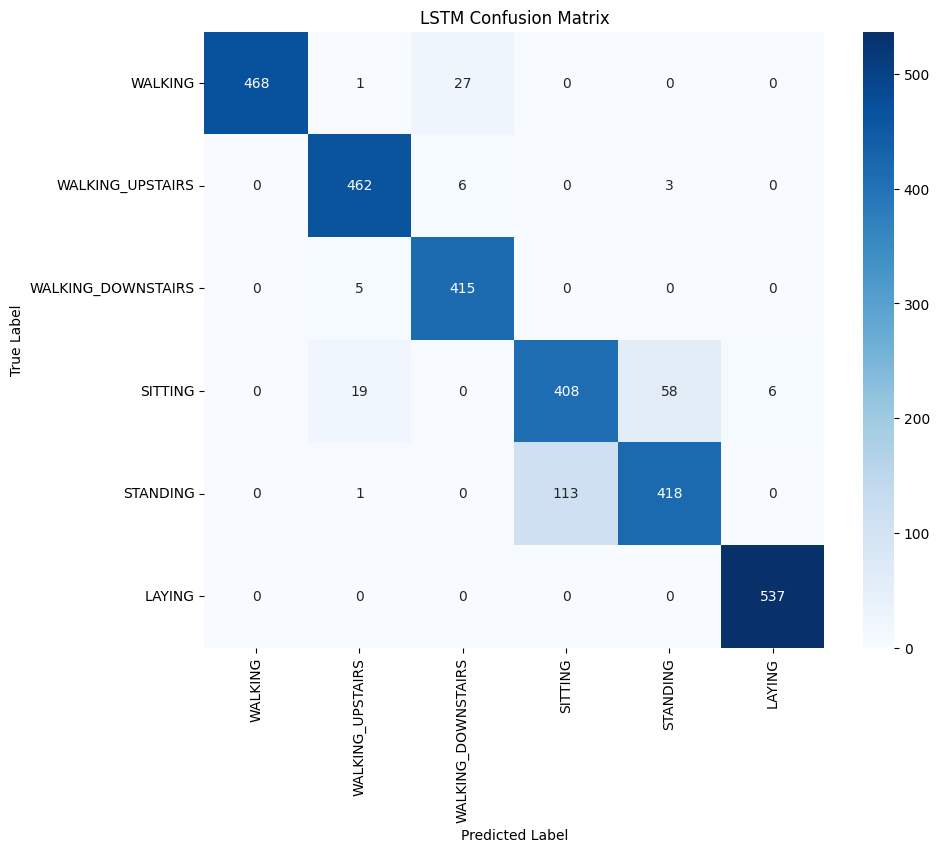

In [27]:
def evaluate_lstm_performance(model, test_loader, device):
    # Set the model to evaluation mode to disable dropout layers
    model.eval()
    all_preds = []
    all_labels = []
    
    # Disable gradient tracking for efficient inference
    with torch.no_grad():
        for inputs, labels in test_loader:
            # Transfer data to the active compute device (MPS/CUDA/CPU)
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass through the trained LSTM
            outputs = model(inputs)
            
            # Extract the class with the highest logit score
            _, predicted = torch.max(outputs, 1)
            
            # Move results back to CPU for evaluation metrics
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    print("\n--- LSTM Performance Report ---")
    
    # Generate human-readable labels for the classification report
    names = [activity_map[i] for i in sorted(activity_map.keys())]
    print(classification_report(all_labels, all_preds, target_names=names))
    
    # Compute the confusion matrix to visualize error distributions
    cm = confusion_matrix(all_labels, all_preds)
    
    # Plot the confusion matrix using a heatmap for better interpretability
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=names, yticklabels=names)
    plt.title('LSTM Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Run the evaluation pipeline
evaluate_lstm_performance(model, test_loader, device)

### Feature Engineering: Magnitude Extraction and Data Scaling

In [28]:
def add_magnitude_features(X):
    # Calculate the Euclidean norm for Body Accelerometer (X, Y, Z)
    body_acc_mag = np.sqrt(np.sum(X[:, :, 0:3]**2, axis=2, keepdims=True))
    
    # Calculate the Euclidean norm for Gyroscope (X, Y, Z)
    gyro_mag = np.sqrt(np.sum(X[:, :, 3:6]**2, axis=2, keepdims=True))
    
    # Calculate the Euclidean norm for Total Accelerometer (X, Y, Z)
    total_acc_mag = np.sqrt(np.sum(X[:, :, 6:9]**2, axis=2, keepdims=True))
    
    # Append the 3 new magnitude channels to the original 9 sensor channels
    # New input shape will be (Batch, Time, 12)
    X_extended = np.concatenate([X, body_acc_mag, gyro_mag, total_acc_mag], axis=2)
    return X_extended

# Apply feature engineering to the training and testing sets
X_train_ext = add_magnitude_features(X_train_np)
X_test_ext = add_magnitude_features(X_test_np)

# Standardize the extended dataset
# Important: Calculate statistics (mean/std) ONLY from the training set to prevent data leakage
ext_train_mean = X_train_ext.mean(axis=(0,1), keepdims=True)
ext_train_std  = X_train_ext.std(axis=(0,1),  keepdims=True)

# Apply Z-score normalization: (x - μ) / σ
X_train_ext_std = (X_train_ext - ext_train_mean) / (ext_train_std)
X_test_ext_std  = (X_test_ext  - ext_train_mean) / (ext_train_std)

# Convert processed NumPy arrays to PyTorch tensors for model compatibility
X_train_ext_t = torch.from_numpy(X_train_ext_std)
X_test_ext_t  = torch.from_numpy(X_test_ext_std)

### LSTM Training with Extended Features and Learning Rate Scheduling

In [29]:
# Initialize DataLoaders using the extended 12-feature tensors
# X_train_ext_t contains the original 9 sensor channels plus 3 magnitude features
train_loader = DataLoader(TensorDataset(X_train_ext_t, y_train_t),
                          batch_size=32, shuffle=True, drop_last=False)
test_loader  = DataLoader(TensorDataset(X_test_ext_t,  y_test_t),
                          batch_size=32, shuffle=False, drop_last=False)

# Update input_size to 12 to accommodate the new engineered features
model = LSTMModel(input_size=12, hidden_size=128, num_classes=6, num_layers=2)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Implement a learning rate scheduler to improve convergence
# It reduces the LR by half if the training loss doesn't improve for 3 consecutive epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
criterion = nn.CrossEntropyLoss()

print("Starting Training with LSTM...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # Update the learning rate based on the average epoch loss
    epoch_loss = running_loss / len(train_loader)
    scheduler.step(epoch_loss)
    
    if (epoch + 1) % 5 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, LR: {current_lr}")

print("Training Finished!")

Starting Training with LSTM...
Epoch [5/30], Loss: 0.1454, LR: 0.001
Epoch [10/30], Loss: 0.1124, LR: 0.001
Epoch [15/30], Loss: 0.1001, LR: 0.0005
Epoch [20/30], Loss: 0.0943, LR: 0.00025
Epoch [25/30], Loss: 0.0922, LR: 0.00025
Epoch [30/30], Loss: 0.0936, LR: 0.00025
Training Finished!



--- LSTM Performance Report ---
                    precision    recall  f1-score   support

           WALKING       0.99      0.97      0.98       496
  WALKING_UPSTAIRS       0.94      0.96      0.95       471
WALKING_DOWNSTAIRS       0.96      0.98      0.97       420
           SITTING       0.81      0.84      0.82       491
          STANDING       0.86      0.82      0.84       532
            LAYING       0.99      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



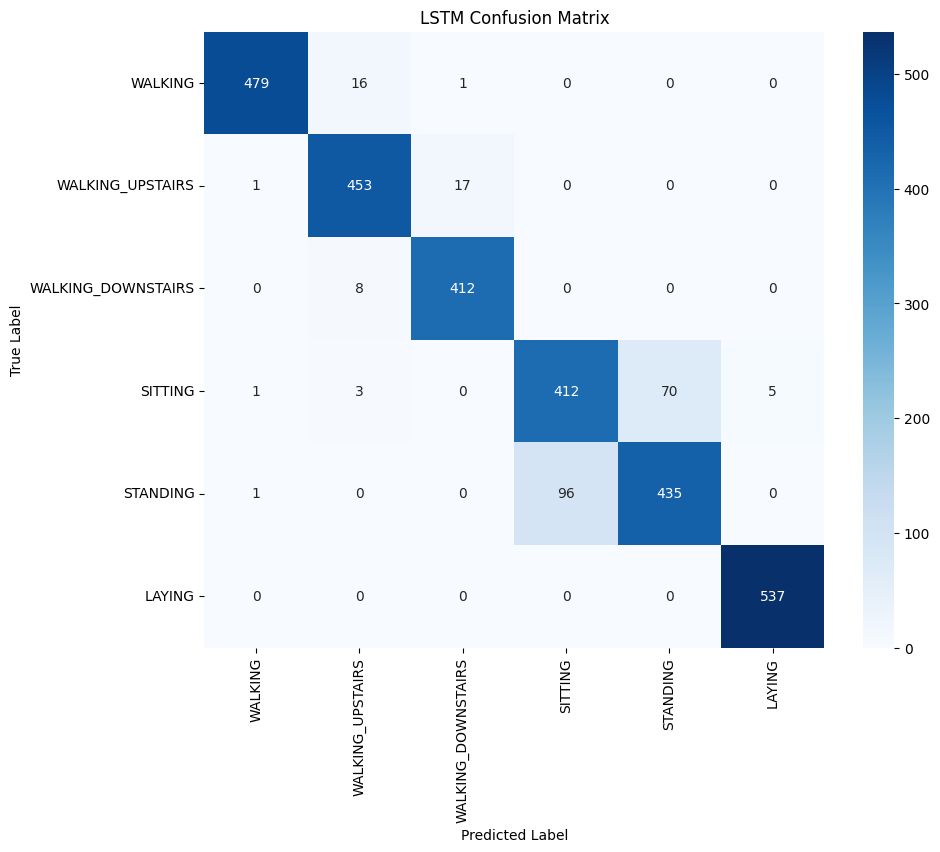

In [30]:
evaluate_lstm_performance(model, test_loader, device)